# Vol 26 — Hull--White, Inflation Swaps & JGBi

**問い:** 名目・実質金利、CPI観測、forward measure、JGBi元本保証を混同せずに評価できるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

CPI fixing/forecast、3か月lag、月次seasonalityを先に固定する。Hull--White 1Fで名目・実質curveを表現し、ZCISとYoYを別cash flowとして評価する。Jarrow--YildirimではCPIを実質economyから名目economyへの為替とみなし、各支払日の名目forward measureを明示する。JGBiは10日基準indexと償還時だけの元本保証を分離し、raw BEIとfloor-adjusted BEIを併記する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'inflation_scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 26
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=26 digest=26f8661dcf2004df arrays=40


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

coupon_floor_max_error: 0.0
floor_adjusted_breakeven_inflation: 0.010228827638702365
floor_decomposition_error: 0.0
floor_mc_zscore_max: 1.1974973083142517
floor_monotone_in_volatility: True
hw_curve_fit_max_error: 0.0
jy_forward_mc_zscore_max: 1.4888912714624325
measure_treatment: nominal_payment_forward
principal_floor_redemption_only: True
raw_breakeven_inflation: 0.00995024875621886
seasonality_annual_log_sum: 1.734723475976807e-18
yoy_convexity_bp: 0.9818821980900339
zcis_repricing_max_error: 0.0


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS hull_white_initial_curve 0.0 <= 1e-12
PASS annual_seasonality_normalization 1.734723475976807e-18 <= 1e-12
PASS zcis_quote_repricing 0.0 <= 1e-10
PASS jy_forward_measure_mc 1.4888912714624325 aligned arrays and maximum analytic/MC z-score < 3
PASS jgbi_floor_analytic_mc 1.1974973083142517 aligned arrays and maximum non-degenerate z-score < 3
PASS floor_volatility_monotonicity True analytic floor is non-decreasing in inflation volatility
PASS redemption_only_principal_floor 0.0 coupons identical and floored final principal exceeds unfloored principal
PASS floor_payoff_decomposition 0.0 <= 1e-12
PASS nominal_payment_forward_measure nominal_payment_forward explicit nominal payment-forward measure with non-zero YoY convexity
PASS raw_and_floor_adjusted_breakeven 0.0002785788824835045 two explicitly different BEI measures
PASS synthetic_hedge_decomposition 2 nominal-duration and CPI-delta residuals are reported separately


## 名目・実質discount curveとnumeraire

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Gly

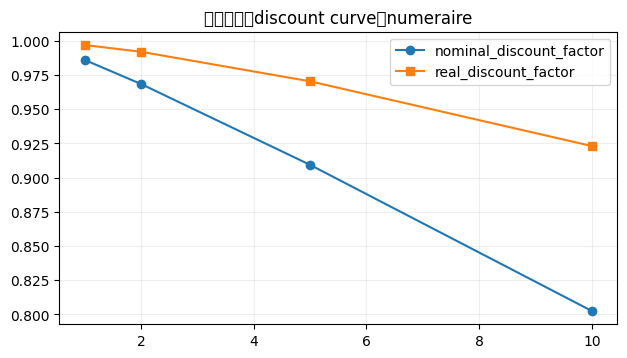

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("名目・実質discount curveとnumeraire")
ax.plot(data["maturity"], data["nominal_discount_factor"], marker="o", label="nominal_discount_factor")
ax.plot(data["maturity"], data["real_discount_factor"], marker="s", label="real_discount_factor")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## CPI trend・fixing・3か月lag・rebasing

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


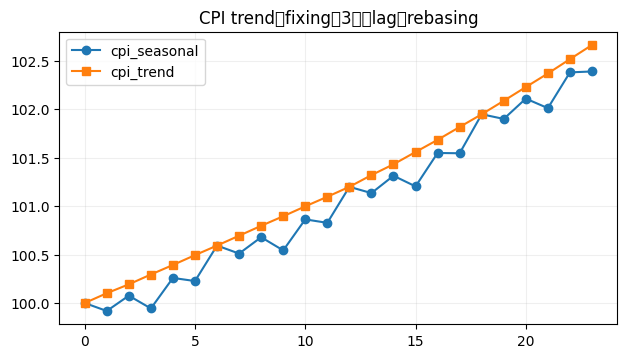

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CPI trend・fixing・3か月lag・rebasing")
ax.plot(data["month_index"], data["cpi_seasonal"], marker="o", label="cpi_seasonal")
ax.plot(data["month_index"], data["cpi_trend"], marker="s", label="cpi_trend")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 決定論的月次seasonality（年率和ゼロ）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27770 (\N{CJK UNIFIED IDEOGRAPH-6C7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarni

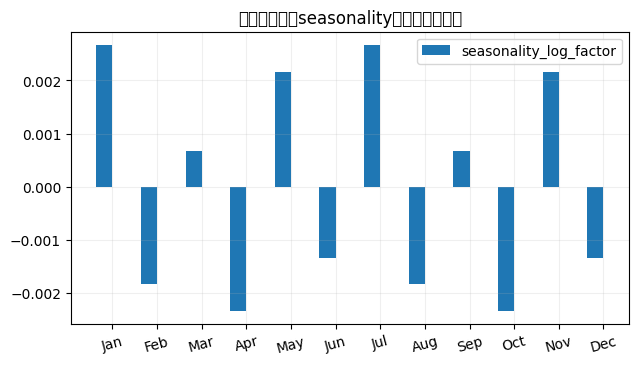

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("決定論的月次seasonality（年率和ゼロ）")
x = np.arange(len(data["month_names"]))
ax.bar(x - .18, data["seasonality_log_factor"], width=.36, label="seasonality_log_factor")
ax.set_xticks(x, data["month_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Hull--White initial-curve fit

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

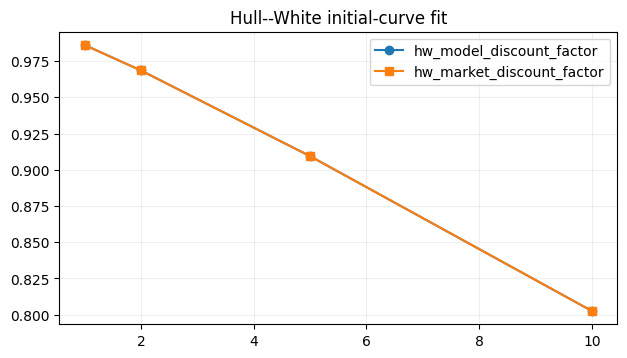

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Hull--White initial-curve fit")
ax.plot(data["maturity"], data["hw_model_discount_factor"], marker="o", label="hw_model_discount_factor")
ax.plot(data["maturity"], data["hw_market_discount_factor"], marker="s", label="hw_market_discount_factor")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Hull--White option ladder

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

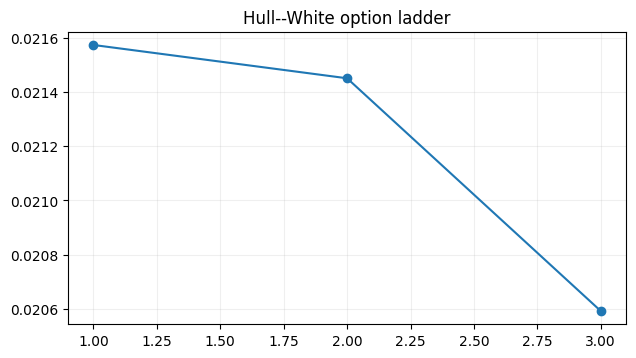

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Hull--White option ladder")
ax.plot(data["hw_swaption_expiry"], data["hw_swaption_price"], marker="o")
ax.grid(alpha=.2)
plt.show()

## ZC inflation swap quote/repricing

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

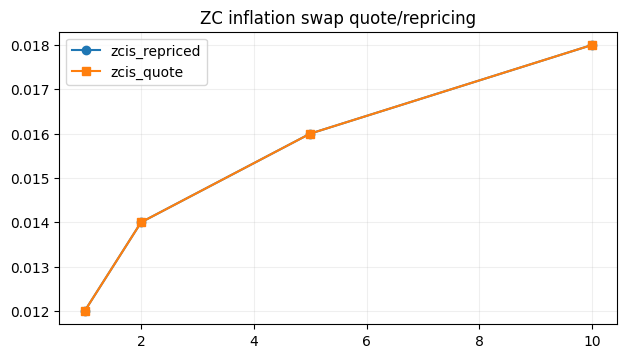

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("ZC inflation swap quote/repricing")
ax.plot(data["zcis_maturity"], data["zcis_repriced"], marker="o", label="zcis_repriced")
ax.plot(data["zcis_maturity"], data["zcis_quote"], marker="s", label="zcis_quote")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## YoY swapとforward-ratio convexity

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


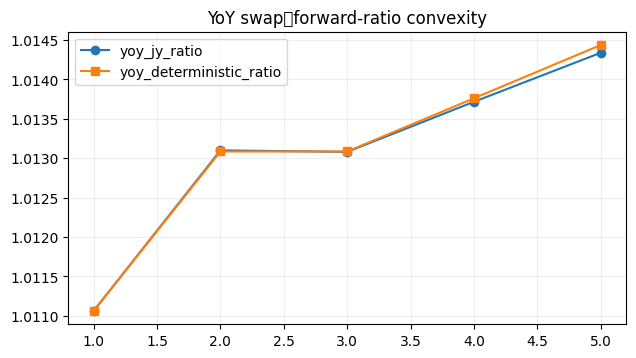

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("YoY swapとforward-ratio convexity")
ax.plot(data["yoy_payment"], data["yoy_jy_ratio"], marker="o", label="yoy_jy_ratio")
ax.plot(data["yoy_payment"], data["yoy_deterministic_ratio"], marker="s", label="yoy_deterministic_ratio")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Jarrow--Yildirim payment-forward measure

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

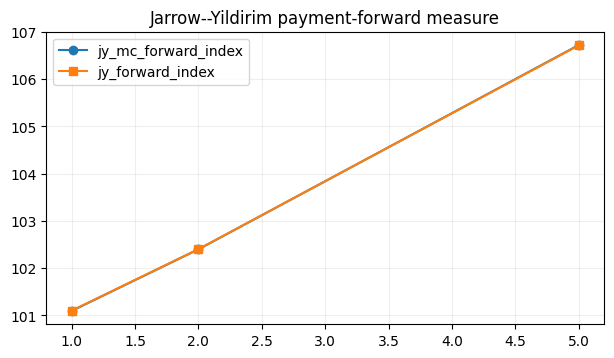

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Jarrow--Yildirim payment-forward measure")
ax.plot(data["jy_observation"], data["jy_mc_forward_index"], marker="o", label="jy_mc_forward_index")
ax.plot(data["jy_observation"], data["jy_forward_index"], marker="s", label="jy_forward_index")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## JGBi cash flow・10日基準index・settlement

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


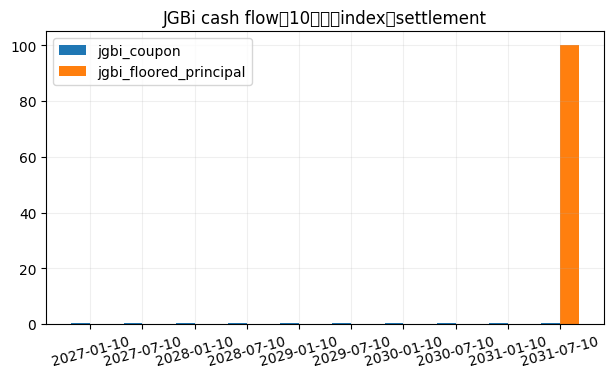

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("JGBi cash flow・10日基準index・settlement")
x = np.arange(len(data["jgbi_cashflow_names"]))
ax.bar(x - .18, data["jgbi_coupon"], width=.36, label="jgbi_coupon")
ax.bar(x + .18, data["jgbi_floored_principal"], width=.36, label="jgbi_floored_principal")
ax.set_xticks(x, data["jgbi_cashflow_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## JGBi deflation floor：analytic vs MC

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


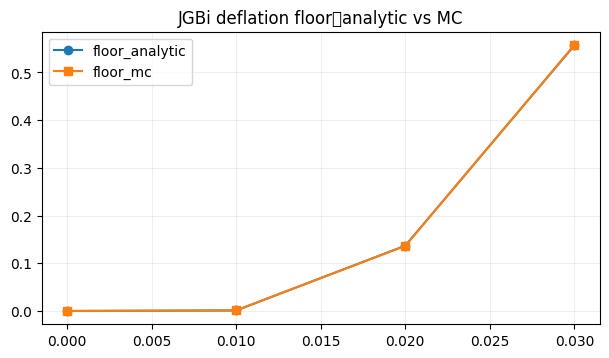

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("JGBi deflation floor：analytic vs MC")
ax.plot(data["inflation_volatility"], data["floor_analytic"], marker="o", label="floor_analytic")
ax.plot(data["inflation_volatility"], data["floor_mc"], marker="s", label="floor_mc")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## raw vs floor-adjusted BEI

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

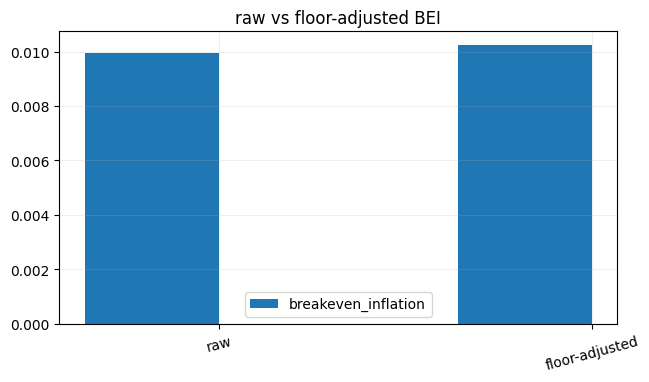

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("raw vs floor-adjusted BEI")
x = np.arange(len(data["bei_names"]))
ax.bar(x - .18, data["breakeven_inflation"], width=.36, label="breakeven_inflation")
ax.set_xticks(x, data["bei_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## JGBi・名目債・inflation swap hedge decomposition

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20661 (\N{CJK UNIFIED IDEOGRAPH-50B5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


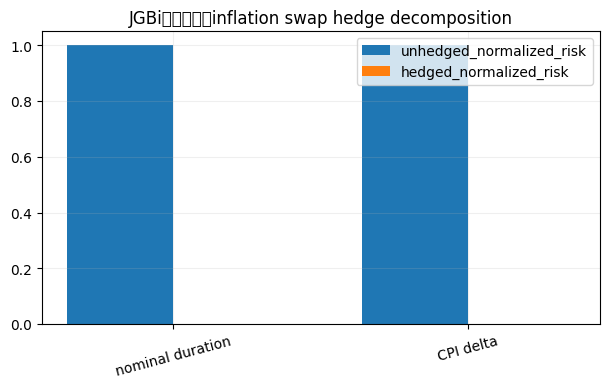

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("JGBi・名目債・inflation swap hedge decomposition")
x = np.arange(len(data["hedge_risk_names"]))
ax.bar(x - .18, data["unhedged_normalized_risk"], width=.36, label="unhedged_normalized_risk")
ax.bar(x + .18, data["hedged_normalized_risk"], width=.36, label="hedged_normalized_risk")
ax.set_xticks(x, data["hedge_risk_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [16]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Hull & White (1990); Jarrow & Yildirim (2003); Ministry of Finance Japan, Inflation-Indexed Bonds product conventions.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。